In [1]:
import os
import glob
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from dotenv import load_dotenv

load_dotenv()

# Hardware setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Define hyperparameters
config = {
    "epochs": 200,
    "batch_size": 8,
    "learning_rate": 1e-4,
    "patch_size": 512,
    "architecture": "DeeperUNet-Sparse-Optimized",
    "loss_function": "L1 + SSIM",
    "patience": 5
}

# Initialize the run
wandb.init(
    project="thomson-denoising", # Your project name
    # name="run-deeper-unet-01", # Optional: give your run a specific name
    config=config
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ash-yz (ash-yz-yazero) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
class DenoisingDataset(Dataset):
    def __init__(self, clean_dir, noisy_dir, crop_size=512):
        self.clean_dir = clean_dir
        self.noisy_dir = noisy_dir
        # Find all noisy images
        self.noisy_paths = glob.glob(os.path.join(noisy_dir, "*.png"))
        self.crop_size = crop_size
        
    def __len__(self):
        return len(self.noisy_paths)
    
    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        
        # Extract clean filename: img_0000_clean_00_noise_00.png -> img_0000_clean_00.png
        basename = os.path.basename(noisy_path)
        clean_name = basename.split('_noise_')[0] + '.png'
        clean_path = os.path.join(self.clean_dir, clean_name)
        
        noisy_img = Image.open(noisy_path).convert('L')
        clean_img = Image.open(clean_path).convert('L')
        
        # Random crop parameters
        i, j, h, w = T.RandomCrop.get_params(noisy_img, output_size=(self.crop_size, self.crop_size))
        
        noisy_img = T.functional.crop(noisy_img, i, j, h, w)
        clean_img = T.functional.crop(clean_img, i, j, h, w)
        
        # Convert to tensor and scale to [0, 1]
        noisy_tensor = T.functional.to_tensor(noisy_img)
        clean_tensor = T.functional.to_tensor(clean_img)
        
        return noisy_tensor, clean_tensor

dataset = DenoisingDataset('clean/', 'noisy/', crop_size=512)

# 1. Define split ratios (90% Train, 10% Validation)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

# 2. Split the dataset
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# 3. Create separate DataLoaders
# If you get "CUDA out of memory", reduce batch_size to 4 or 2.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

# Grab a fixed batch for visual logging
fixed_val_noisy, fixed_val_clean = next(iter(val_loader))
fixed_val_noisy = fixed_val_noisy.to(device)
fixed_val_clean = fixed_val_clean.to(device)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Training samples: 480 | Validation samples: 54


In [4]:
class DeeperUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        
        def double_conv(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=not norm)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            layers.append(nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=not norm))
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        
        # Outer layers (d1, u3) have no norm to prevent signal washing
        self.d1 = double_conv(in_channels, 64, norm=False)
        self.d2 = double_conv(64, 128)
        self.d3 = double_conv(128, 256)
        self.d4 = double_conv(256, 512)
        
        self.pool = nn.MaxPool2d(2)
        
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.u1 = double_conv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.u2 = double_conv(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.u3 = double_conv(128, 64, norm=False)
        
        self.out = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.ReLU() # Signals are positive and sparse; Sigmoid asymptotes too early
        )

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.pool(x1))
        x3 = self.d3(self.pool(x2))
        x4 = self.d4(self.pool(x3))
        
        x = self.up1(x4); x = torch.cat([x, x3], dim=1); x = self.u1(x)
        x = self.up2(x); x = torch.cat([x, x2], dim=1); x = self.u2(x)
        x = self.up3(x); x = torch.cat([x, x1], dim=1); x = self.u3(x)
        
        return self.out(x)

model = DeeperUNet().to(device)

In [5]:
from pytorch_msssim import ssim
import torch.nn.functional as F

def composite_loss(pred, target):
    # 1. Pixel-wise L1 Loss
    l1_loss = F.l1_loss(pred, target, reduction='none')
    
    # 2. Spatial Weighting: Give 10x importance to pixels that ARE the arc in Ground Truth
    # Higher threshold (0.05) to ensure we aren't weighting the noise floor
    weight_mask = torch.where(target > 0.05, 15.0, 1.0)
    weighted_l1 = (l1_loss * weight_mask).mean()
    
    # 3. MSE Loss: Penalizes large errors on high-intensity peaks
    mse_loss = F.mse_loss(pred, target)
    
    # 4. SSIM: Useful for structural continuity of the parabola
    # Use a small window (7) for thin features
    ssim_val = ssim(pred, target, data_range=1.0, size_average=True, win_size=7)
    
    return weighted_l1 + (2.0 * mse_loss) + (1.0 - ssim_val)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')

In [6]:
import os
import torch
# import wandb  # Assumed imported previously

epochs = config['epochs']
patience = config['patience']
epochs_no_improve = 0
best_val_loss = float('inf')

train_loss_history = []
val_loss_history = []

# Create checkpoints directory
os.makedirs('checkpoints', exist_ok=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Add this at the end of the Validation Phase loop:
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0
    
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            preds = model(noisy)
            loss = composite_loss(preds, clean)

        # Move scaling and backward outside autocast
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        # Critical Fix: Accumulate the loss
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for noisy_val, clean_val in val_loader:
            noisy_val, clean_val = noisy_val.to(device), clean_val.to(device)
            with torch.amp.autocast('cuda'):
                preds_val = model(noisy_val)
                val_loss = composite_loss(preds_val, clean_val)
            epoch_val_loss += val_loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
    
    # Log metrics to Weights & Biases
    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "epoch": epoch + 1
    })
    
    scheduler.step(avg_val_loss)
    # Early Stopping & Checkpointing Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        
        checkpoint_path = "checkpoints/unet_denoise_best.pth"
        torch.save(model.state_dict(), checkpoint_path)
        
        # Optionally back up the best checkpoint to W&B cloud storage
        # wandb.save(checkpoint_path, base_path="checkpoints")
        
        print(f"--> Saved new best model (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"    No improvement. Early stopping counter: {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

Epoch 1/200 - Train Loss: 0.1357 - Val Loss: 0.1638
--> Saved new best model (Val Loss: 0.1638)
Epoch 2/200 - Train Loss: 0.1065 - Val Loss: 0.0797
--> Saved new best model (Val Loss: 0.0797)
Epoch 3/200 - Train Loss: 0.0653 - Val Loss: 0.0529
--> Saved new best model (Val Loss: 0.0529)
Epoch 4/200 - Train Loss: 0.0659 - Val Loss: 0.0645
    No improvement. Early stopping counter: 1/5
Epoch 5/200 - Train Loss: 0.0633 - Val Loss: 0.0646
    No improvement. Early stopping counter: 2/5
Epoch 6/200 - Train Loss: 0.0706 - Val Loss: 0.0700
    No improvement. Early stopping counter: 3/5
Epoch 7/200 - Train Loss: 0.0681 - Val Loss: 0.0780
    No improvement. Early stopping counter: 4/5
Epoch 8/200 - Train Loss: 0.0644 - Val Loss: 0.0405
--> Saved new best model (Val Loss: 0.0405)
Epoch 9/200 - Train Loss: 0.0611 - Val Loss: 0.0778
    No improvement. Early stopping counter: 1/5
Epoch 10/200 - Train Loss: 0.0572 - Val Loss: 0.0749
    No improvement. Early stopping counter: 2/5
Epoch 11/200 - 

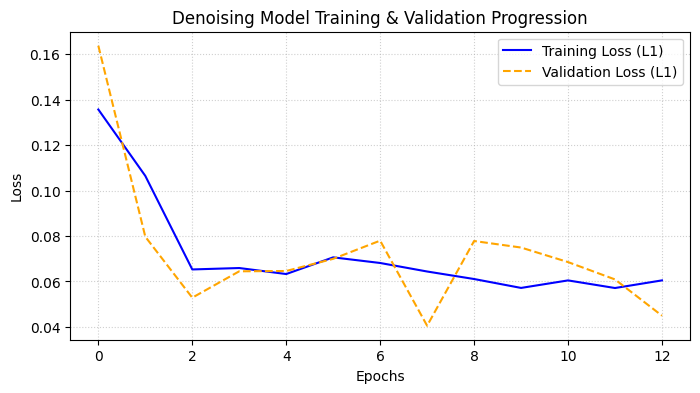

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Training Loss (L1)', color='blue')
plt.plot(val_loss_history, label='Validation Loss (L1)', color='orange', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Denoising Model Training & Validation Progression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

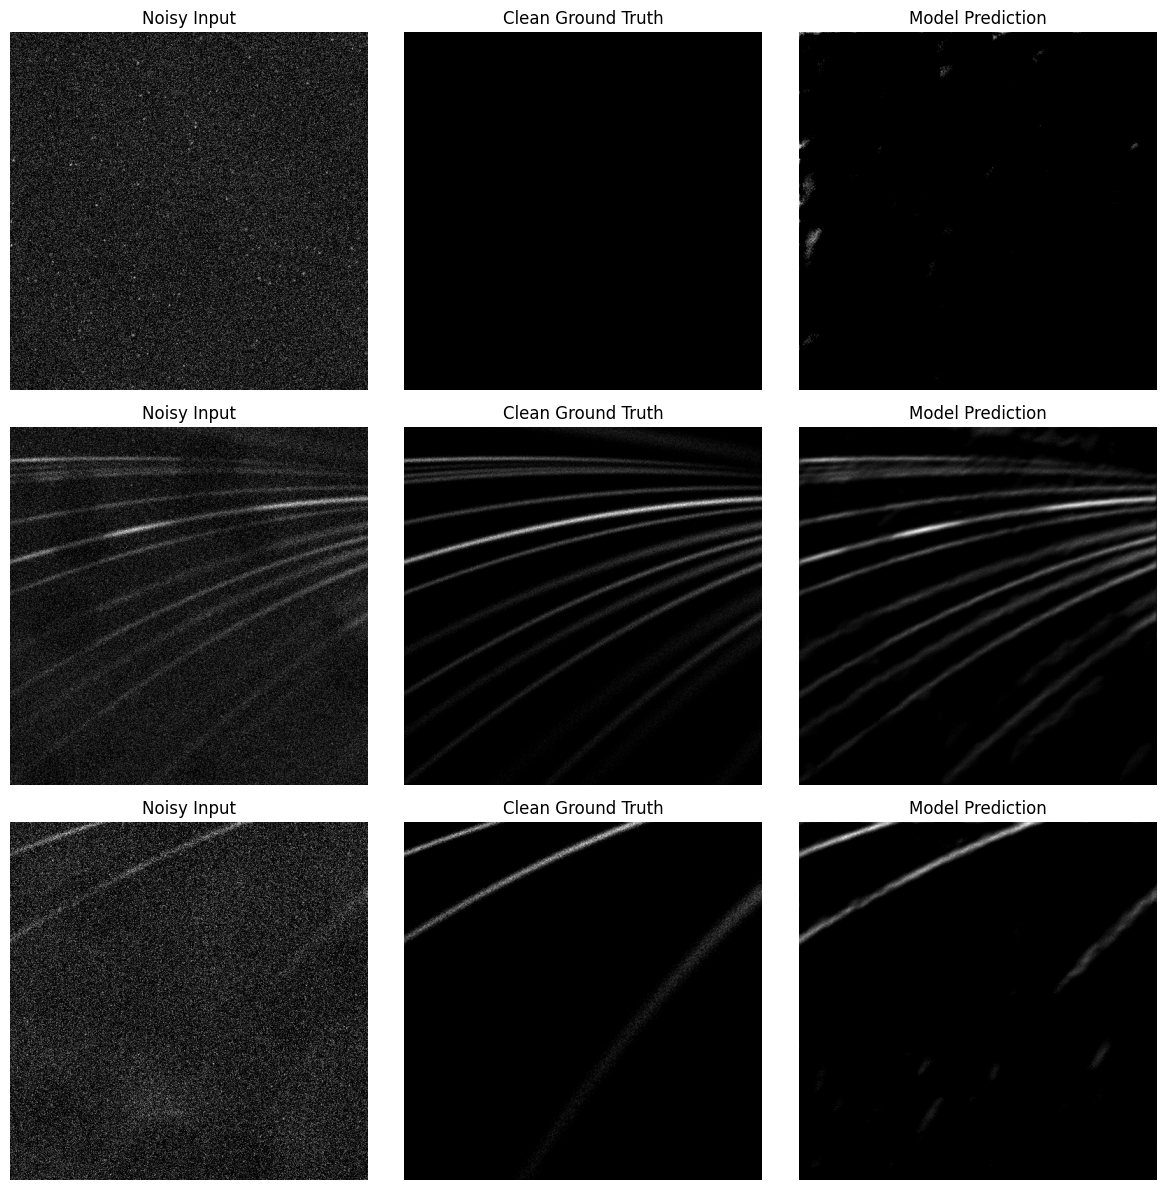

In [8]:
# After the training loop and before inference
model.load_state_dict(torch.load("checkpoints/unet_denoise_best.pth"))
model.eval()
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        fixed_preds = model(fixed_val_noisy)
    
    fixed_preds = torch.clamp(fixed_preds, 0.0, 1.0)
    fixed_gt = fixed_val_clean
    
    # Limit to 3 images to prevent excessive W&B storage usage
    num_images_to_log = min(3, fixed_val_noisy.size(0))
    logged_visuals = []
    
    for i in range(num_images_to_log):
        # Concatenate along the width dimension (dim=2 for C, H, W)
        # Layout: [Noisy Input] | [Clean Ground Truth] | [Model Prediction]
        combined_image = torch.cat([fixed_val_noisy[i], fixed_gt[i], fixed_preds[i]], dim=2)
        
        logged_visuals.append(
            wandb.Image(combined_image, caption=f"Epoch {epoch+1}: Noisy | GT | Pred (Sample {i})")
        )

# Log metrics and images to Weights & Biases
wandb.log({
    "train_loss": avg_train_loss,
    "val_loss": avg_val_loss,
    "epoch": epoch + 1,
    "validation_samples": logged_visuals
})

# Run inference on a PNG file
with torch.no_grad():
    # Grab one batch
    noisy_viz, clean_viz = next(iter(train_loader))
    noisy_viz, clean_viz = noisy_viz.to(device), clean_viz.to(device)
    
    preds_viz = model(noisy_viz)
    
    # Show first 3 images in the batch
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i in range(3):
        # Convert tensors to numpy (H, W, C)
        n_img = noisy_viz[i].cpu().squeeze().numpy()
        c_img = clean_viz[i].cpu().squeeze().numpy()
        p_img = preds_viz[i].cpu().squeeze().numpy()

        axes[i, 0].imshow(n_img, cmap='gray'); axes[i, 0].set_title("Noisy Input")
        axes[i, 1].imshow(c_img, cmap='gray'); axes[i, 1].set_title("Clean Ground Truth")
        axes[i, 2].imshow(p_img, cmap='gray'); axes[i, 2].set_title("Model Prediction")
        
        for ax in axes[i]: ax.axis('off')
plt.tight_layout()
plt.show()

# If predictions look like gray blobs: The model collapsed. Check learning rate or normalize inputs.
# If predictions look identical to noisy input: The network is passing the identity. Increase model capacity.

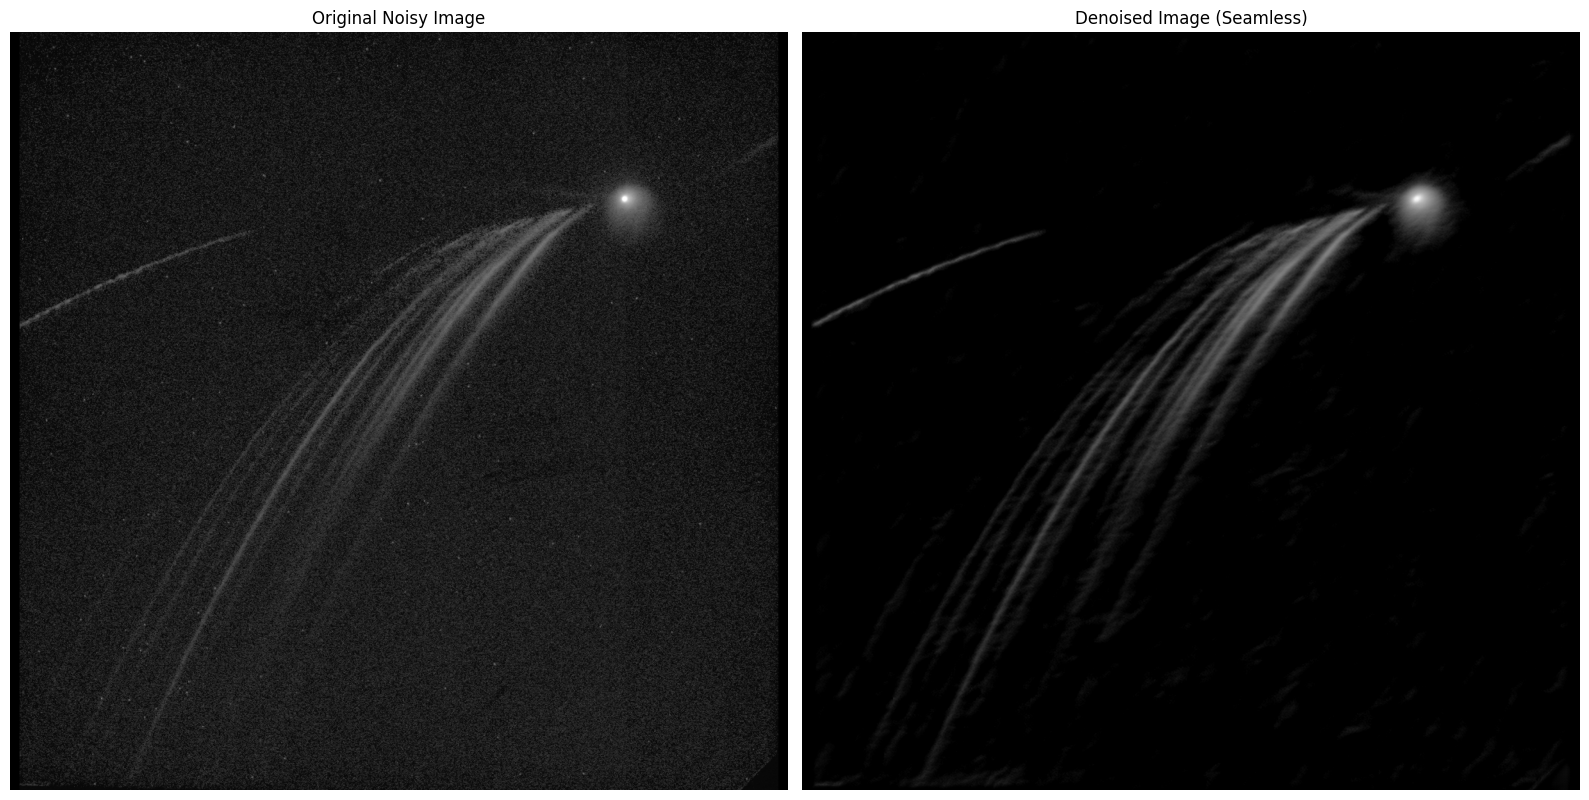

In [27]:
import torch.nn.functional as F
from PIL import Image
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt

def create_window(window_size):
    """Creates a 2D Hann window to blend overlapping patches."""
    window_1d = torch.hann_window(window_size)
    window_2d = window_1d.unsqueeze(1) * window_1d.unsqueeze(0)
    return window_2d.unsqueeze(0).unsqueeze(0).to(device) # Shape: (1, 1, H, W)

def denoise_large_image(image_path, model, patch_size=config['patch_size'], stride=256):
    model.eval()
    
    # Read and prepare image using PIL
    img = Image.open(image_path).convert('L')
    # img = img.resize((2000, 2000))
    img = img.transpose(Image.FLIP_LEFT_RIGHT).rotate(90)
    img_tensor = T.functional.to_tensor(img).unsqueeze(0).to(device)
    
    _, channels, h, w = img_tensor.shape
    
    # Calculate right/bottom padding to ensure stride divisibility
    pad_h_extra = (stride - h % stride) % stride
    pad_w_extra = (stride - w % stride) % stride

    # Add an additional half-patch symmetric padding 
    pad_top = patch_size // 2
    pad_bottom = (patch_size // 2) + pad_h_extra
    pad_left = patch_size // 2
    pad_right = (patch_size // 2) + pad_w_extra

    # Pad image using reflection
    padded_img = F.pad(img_tensor, (pad_left, pad_right, pad_top, pad_bottom), mode='reflect')
    _, _, padded_h, padded_w = padded_img.shape
    
    # Accumulators for the final image and the blending weights
    output_tensor = torch.zeros_like(padded_img)
    weight_accumulator = torch.zeros((1, 1, padded_h, padded_w), device=device)
    
    window = create_window(patch_size)
    
    with torch.no_grad():
        for y in range(0, padded_h - patch_size + 1, stride):
            for x in range(0, padded_w - patch_size + 1, stride):
                # Extract patch
                patch = padded_img[:, :, y:y+patch_size, x:x+patch_size]
                
                # Predict
                pred_patch = model(patch) 
                # Reverse the [0.05, 0.95] scaling back to [0, 1]
                pred_patch = torch.clamp(pred_patch, 0.0, 1.0)
                
                # Apply window and accumulate
                output_tensor[:, :, y:y+patch_size, x:x+patch_size] += pred_patch * window
                weight_accumulator[:, :, y:y+patch_size, x:x+patch_size] += window
                
    output_tensor = output_tensor / (weight_accumulator + 1e-5)

    # Crop back to original dimensions using the top and left offsets
    final_output = output_tensor[:, :, pad_top:pad_top+h, pad_left:pad_left+w]
    
    # Format both original and output for Matplotlib (H, W)
    # Note: Removed .permute(1, 2, 0) because .squeeze() on a [1, 1, H, W] grayscale tensor 
    # yields a 2D [H, W] array. Calling permute on a 2D array throws a runtime error.
    input_np = img_tensor.squeeze().cpu().numpy()
    output_np = final_output.squeeze().cpu().numpy()
    
    # Return both the original and the clipped denoised image
    return input_np, np.clip(output_np, 0, 1)

# Run inference on a PNG file
noisy_png, denoised_png = denoise_large_image('ex3.png', model, patch_size=config['patch_size'], stride=256)

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(noisy_png, cmap='gray')
axes[0].set_title("Original Noisy Image")
axes[0].axis('off')

axes[1].imshow(denoised_png, cmap='gray')
axes[1].set_title("Denoised Image (Seamless)")
axes[1].axis('off')

img = Image.fromarray((denoised_png * 255).astype(np.uint8)).rotate(-90).transpose(Image.FLIP_LEFT_RIGHT).convert('RGB').save('denoised.png')
plt.tight_layout()
plt.show()